# Primer análisis: 
Voy a coger una barrera 'transparente', es decir, que el material de la barrera y el del medio sea el mismo, por lo que las masas efectivas son las mismas.
También voy a experimentar cambiando la masa efectiva de la barrera

Suponiendo que la energía de los KIENES es como máximo 0.1 eV, he ido cambiando la longitud de la barrera y me he quedado con el valor del coeficiente de transmisión para esa energía. 

Queremos buscar una barrera que permita que pasen, como máximo. 0.01% de los KIENES incidentes, es decir, T<$10^{-4}$

AJUSTE PARA m = 0.067
A1 = 2.644308855481297
B1 = 1.4311348175477145
T1(L) = 2.644309e+00 * exp(-1.431135 * L)

AJUSTE PARA m = 0.09
A2 = 2.9674076125472832
B2 = 1.656464293525945
T2(L) = 2.967408e+00 * exp(-1.656464 * L)


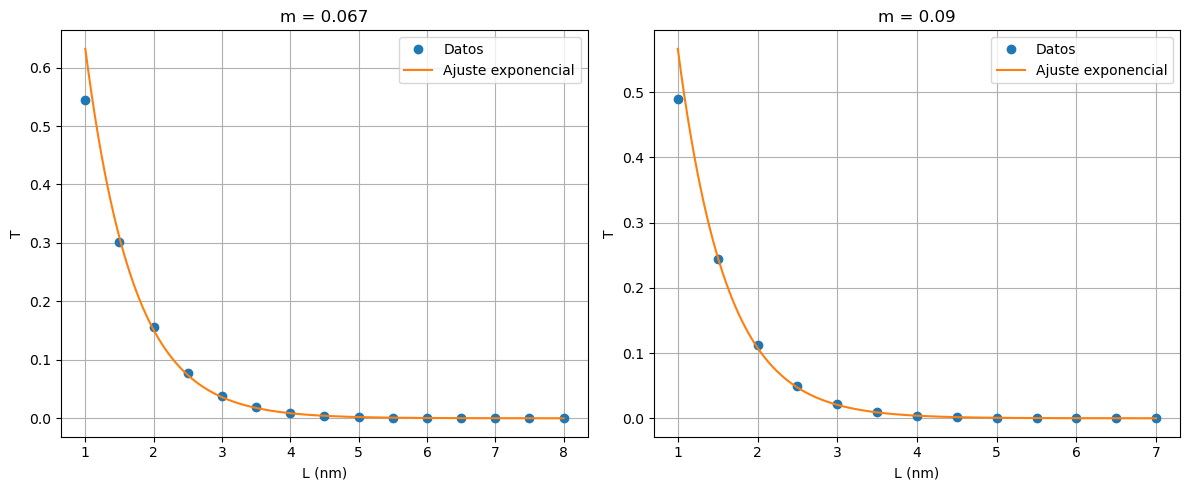

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LEER LOS DOS ARCHIVOS
# =========================

matriz1 = np.loadtxt("T-L,E=0.1,m=0.067.txt", skiprows=1)
matriz2 = np.loadtxt("T-L,E=0.1,m=0.09.txt", skiprows=1)

L1 = matriz1[:, 0]
T1 = matriz1[:, 1]

L2 = matriz2[:, 0]
T2 = matriz2[:, 1]

# =========================
# AJUSTES EXPONENCIALES
# T(L) = A * exp(-B*L)
# ln(T) = ln(A) - B*L
# =========================

coef1 = np.polyfit(L1, np.log(T1), 1)
pendiente1 = coef1[0]
ordenada1 = coef1[1]

B1 = -pendiente1
A1 = np.exp(ordenada1)

coef2 = np.polyfit(L2, np.log(T2), 1)
pendiente2 = coef2[0]
ordenada2 = coef2[1]

B2 = -pendiente2
A2 = np.exp(ordenada2)

print("AJUSTE PARA m = 0.067")
print("A1 =", A1)
print("B1 =", B1)
print(f"T1(L) = {A1:.6e} * exp(-{B1:.6f} * L)")
print()

print("AJUSTE PARA m = 0.09")
print("A2 =", A2)
print("B2 =", B2)
print(f"T2(L) = {A2:.6e} * exp(-{B2:.6f} * L)")

# =========================
# CURVAS DE AJUSTE
# =========================

L1_ajuste = np.linspace(min(L1), max(L1), 300)
T1_ajuste = A1 * np.exp(-B1 * L1_ajuste)

L2_ajuste = np.linspace(min(L2), max(L2), 300)
T2_ajuste = A2 * np.exp(-B2 * L2_ajuste)

# =========================
# GRAFICAS LADO A LADO
# =========================

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(L1, T1, 'o', label="Datos")
plt.plot(L1_ajuste, T1_ajuste, '-', label="Ajuste exponencial")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.067")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(L2, T2, 'o', label="Datos")
plt.plot(L2_ajuste, T2_ajuste, '-', label="Ajuste exponencial")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.09")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

para que se vea mejor el ajuste

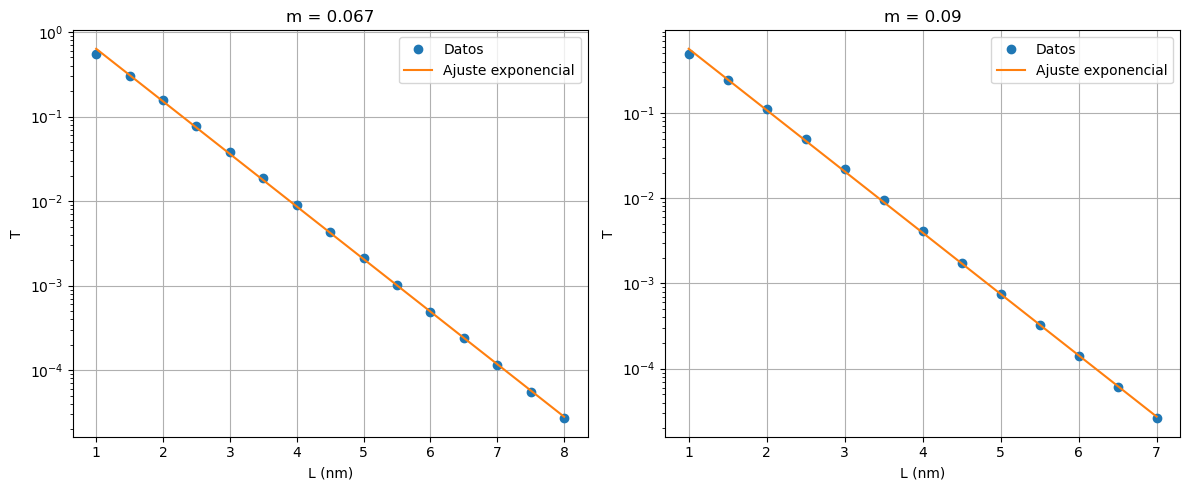

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.semilogy(L1, T1, 'o', label="Datos")
plt.semilogy(L1_ajuste, T1_ajuste, '-', label="Ajuste exponencial")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.067")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(L2, T2, 'o', label="Datos")
plt.semilogy(L2_ajuste, T2_ajuste, '-', label="Ajuste exponencial")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.09")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()